# New Uploaded Invoice Extraction and Customer Matching

This notebook prepares the invoice extraction part of Finplex AI.

The goal is not to upload an invoice that already exists in ERP and simply find the same invoice row. That would not be useful.

Instead, this notebook follows the real application flow:

1. Use a public accounts-receivable dataset as historical ERP/CRM data.
2. Build historical customer payment records from that dataset.
3. Generate new invoice images for existing customers.
4. Extract fields from the new invoice images using OCR.
5. Match the extracted customer information to historical ERP/CRM records.
6. Save demo invoice images and seed data for the application.

The new invoice images are not copied from the historical ERP invoice rows. They represent new uploaded invoices for customers that already have payment history.

This makes the project useful because Finplex AI predicts late-payment risk from customer behavior, not from already knowing the uploaded invoice.

## 1. Install Required Packages

This notebook uses:

- KaggleHub to download the public accounts-receivable dataset;
- pandas and numpy for data preparation;
- Pillow to generate clean invoice images;
- Tesseract OCR to read the generated invoices;
- OpenCV for image preprocessing;
- matplotlib for invoice preview;
- tqdm for progress bars.

In [1]:
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr

!pip install -q kagglehub pandas numpy pillow pytesseract opencv-python matplotlib tqdm

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 2. Import Libraries and Create Folders

The notebook creates folders for raw data, historical seed data, generated demo invoices, and extraction artifacts.

In [2]:
from pathlib import Path
from datetime import datetime, UTC
import json
import random
import re
import shutil

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytesseract
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
SEED_DIR = DATA_DIR / "seed"
DEMO_INVOICE_DIR = DATA_DIR / "demo_invoices" / "new_uploaded_invoices"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "invoice_extraction"

for folder in [
    RAW_DATA_DIR,
    SEED_DIR,
    DEMO_INVOICE_DIR,
    ARTIFACTS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Seed data folder:", SEED_DIR)
print("Demo invoice folder:", DEMO_INVOICE_DIR)
print("Artifacts folder:", ARTIFACTS_DIR)

Project root: /content
Raw data folder: /content/data/raw
Seed data folder: /content/data/seed
Demo invoice folder: /content/data/demo_invoices/new_uploaded_invoices
Artifacts folder: /content/artifacts/invoice_extraction


## 3. Download the Public Accounts-Receivable Dataset

The dataset used in this notebook is the IBM late-payment histories dataset.

It represents historical accounts-receivable invoice behavior. In the project, this dataset is used as a local substitute for ERP/CRM systems such as Oracle, Salesforce, NetSuite, or Odoo.

If the automatic download fails, the notebook lets me upload the CSV manually.

In [3]:
DATASET_SLUG = "hhenry/finance-factoring-ibm-late-payment-histories"

csv_path = None

try:
    downloaded_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    print("Downloaded dataset folder:", downloaded_path)

    csv_files = sorted(downloaded_path.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded dataset.")

    csv_path = csv_files[0]
    print("Selected CSV:", csv_path)

except Exception as exc:
    print("Automatic KaggleHub download failed.")
    print(exc)
    print("Upload the accounts receivable CSV manually.")

    try:
        from google.colab import files

        uploaded = files.upload()

        uploaded_csv_files = [
            filename
            for filename in uploaded
            if filename.lower().endswith(".csv")
        ]

        if not uploaded_csv_files:
            raise FileNotFoundError("No CSV file was uploaded.")

        uploaded_filename = uploaded_csv_files[0]
        csv_path = RAW_DATA_DIR / uploaded_filename
        csv_path.write_bytes(uploaded[uploaded_filename])

        print("Uploaded CSV saved to:", csv_path)

    except Exception as upload_exc:
        raise RuntimeError(
            "Could not download or upload the accounts receivable dataset."
        ) from upload_exc

raw_dataset_path = RAW_DATA_DIR / "accounts_receivable_history.csv"
shutil.copy2(csv_path, raw_dataset_path)

print("Raw dataset copied to:", raw_dataset_path)

100%|██████████| 56.8k/56.8k [00:00<00:00, 39.4MB/s]

Extracting files...
Downloaded dataset folder: /root/.cache/kagglehub/datasets/hhenry/finance-factoring-ibm-late-payment-histories/versions/1
Selected CSV: /root/.cache/kagglehub/datasets/hhenry/finance-factoring-ibm-late-payment-histories/versions/1/WA_Fn-UseC_-Accounts-Receivable.csv
Raw dataset copied to: /content/data/raw/accounts_receivable_history.csv


## 4. Load and Validate the Dataset

This cell loads the public accounts-receivable dataset and checks the required columns.

The columns are used to build historical ERP/CRM tables and customer payment history.

In [4]:
history_df = pd.read_csv(raw_dataset_path)

print("Dataset shape:", history_df.shape)
display(history_df.head())

print("Columns:")
print(history_df.columns.tolist())

required_columns = [
    "countryCode",
    "customerID",
    "invoiceNumber",
    "InvoiceDate",
    "DueDate",
    "InvoiceAmount",
    "Disputed",
    "SettledDate",
    "PaperlessBill",
    "DaysToSettle",
    "DaysLate",
]

missing_columns = [
    column
    for column in required_columns
    if column not in history_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing expected columns: "
        + ", ".join(missing_columns)
        + "\nAvailable columns: "
        + ", ".join(history_df.columns.astype(str))
    )

print("All required columns are available.")

Dataset shape: (2466, 12)


,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,391,0379-NEVHP,4/6/2013,611365,1/2/2013,2/1/2013,55.94,No,1/15/2013,Paper,13,0
1,406,8976-AMJEO,3/3/2012,7900770,1/26/2013,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6
2,391,2820-XGXSB,1/26/2012,9231909,7/3/2013,8/2/2013,65.88,No,7/8/2013,Electronic,5,0
3,406,9322-YCTQO,4/6/2012,9888306,2/10/2013,3/12/2013,105.92,No,3/17/2013,Electronic,35,5
4,818,6627-ELFBK,11/26/2012,15752855,10/25/2012,11/24/2012,72.27,Yes,11/28/2012,Paper,34,4


Columns:
['countryCode', 'customerID', 'PaperlessDate', 'invoiceNumber', 'InvoiceDate', 'DueDate', 'InvoiceAmount', 'Disputed', 'SettledDate', 'PaperlessBill', 'DaysToSettle', 'DaysLate']
All required columns are available.


## 5. Clean Historical ERP/CRM Data

This section cleans the public dataset and converts it into Finplex-style historical ERP/CRM records.

These records represent old invoices and old payment behavior. They are not the new uploaded invoices.

In [5]:
def parse_yes_no(value) -> int:
    value = str(value).strip().lower()

    if value in {"yes", "y", "true", "1"}:
        return 1

    if value in {"no", "n", "false", "0"}:
        return 0

    return 0


clean_history_df = history_df.copy()

clean_history_df["countryCode"] = clean_history_df["countryCode"].astype(str).str.strip()
clean_history_df["customerID"] = clean_history_df["customerID"].astype(str).str.strip()
clean_history_df["invoiceNumber"] = clean_history_df["invoiceNumber"].astype(str).str.strip()

clean_history_df["InvoiceDate"] = pd.to_datetime(
    clean_history_df["InvoiceDate"],
    errors="coerce",
)

clean_history_df["DueDate"] = pd.to_datetime(
    clean_history_df["DueDate"],
    errors="coerce",
)

clean_history_df["SettledDate"] = pd.to_datetime(
    clean_history_df["SettledDate"],
    errors="coerce",
)

clean_history_df["InvoiceAmount"] = pd.to_numeric(
    clean_history_df["InvoiceAmount"],
    errors="coerce",
)

clean_history_df["DaysToSettle"] = pd.to_numeric(
    clean_history_df["DaysToSettle"],
    errors="coerce",
)

clean_history_df["DaysLate"] = pd.to_numeric(
    clean_history_df["DaysLate"],
    errors="coerce",
).fillna(0)

clean_history_df["Disputed"] = clean_history_df["Disputed"].apply(parse_yes_no)
clean_history_df["PaperlessBill"] = clean_history_df["PaperlessBill"].apply(parse_yes_no)

clean_history_df = clean_history_df.dropna(
    subset=[
        "customerID",
        "invoiceNumber",
        "InvoiceDate",
        "DueDate",
        "InvoiceAmount",
    ]
).copy()

clean_history_df = clean_history_df[clean_history_df["InvoiceAmount"] > 0].copy()

clean_history_df["tenant_id"] = "tenant_demo"
clean_history_df["currency"] = "USD"

clean_history_df["finplex_customer_id"] = clean_history_df["customerID"].apply(
    lambda value: f"cust_{value}"
)

clean_history_df["customer_name"] = clean_history_df["customerID"].apply(
    lambda value: f"Customer {value}"
)

clean_history_df["historical_invoice_id"] = [
    f"hist_inv_{index:05d}"
    for index in range(len(clean_history_df))
]

clean_history_df["invoice_date"] = clean_history_df["InvoiceDate"].dt.strftime("%Y-%m-%d")
clean_history_df["due_date"] = clean_history_df["DueDate"].dt.strftime("%Y-%m-%d")
clean_history_df["settled_date"] = clean_history_df["SettledDate"].dt.strftime("%Y-%m-%d")

clean_history_df["amount_due"] = clean_history_df["InvoiceAmount"].round(2)
clean_history_df["days_late"] = clean_history_df["DaysLate"].astype(int)
clean_history_df["days_overdue"] = clean_history_df["DaysLate"].clip(lower=0).astype(int)

clean_history_df["payment_terms_days"] = (
    clean_history_df["DueDate"] - clean_history_df["InvoiceDate"]
).dt.days.clip(lower=0)

clean_history_df = clean_history_df.sort_values(
    ["customerID", "InvoiceDate", "invoiceNumber"]
).reset_index(drop=True)

print("Clean historical rows:", len(clean_history_df))
display(clean_history_df.head())

Clean historical rows: 2466


,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,...,finplex_customer_id,customer_name,historical_invoice_id,invoice_date,due_date,settled_date,amount_due,days_late,days_overdue,payment_terms_days
0,391,0187-ERLSR,7/31/2013,4037644863,2012-03-29,2012-04-28,62.68,1,2012-04-25,0,...,cust_0187-ERLSR,Customer 0187-ERLSR,hist_inv_00991,2012-03-29,2012-04-28,2012-04-25,62.68,0,0,30
1,391,0187-ERLSR,7/31/2013,9471530987,2012-05-15,2012-06-14,77.19,0,2012-05-28,0,...,cust_0187-ERLSR,Customer 0187-ERLSR,hist_inv_02345,2012-05-15,2012-06-14,2012-05-28,77.19,0,0,30
2,391,0187-ERLSR,7/31/2013,9744145268,2012-05-21,2012-06-20,51.65,0,2012-06-04,0,...,cust_0187-ERLSR,Customer 0187-ERLSR,hist_inv_02401,2012-05-21,2012-06-20,2012-06-04,51.65,0,0,30
3,391,0187-ERLSR,7/31/2013,7214076449,2012-06-16,2012-07-16,64.47,1,2012-07-04,0,...,cust_0187-ERLSR,Customer 0187-ERLSR,hist_inv_01791,2012-06-16,2012-07-16,2012-07-04,64.47,0,0,30
4,391,0187-ERLSR,7/31/2013,1756742390,2012-09-05,2012-10-05,84.57,0,2012-09-14,0,...,cust_0187-ERLSR,Customer 0187-ERLSR,hist_inv_00445,2012-09-05,2012-10-05,2012-09-14,84.57,0,0,30


## 6. Save Historical ERP and CRM Seed Tables

These files simulate local ERP/CRM data.

The generated demo invoices will be new invoices for existing customers. The application should use the extracted customer information to look up these historical records.

In [6]:
historical_erp_invoices_df = clean_history_df[
    [
        "tenant_id",
        "historical_invoice_id",
        "invoiceNumber",
        "finplex_customer_id",
        "customerID",
        "customer_name",
        "invoice_date",
        "due_date",
        "payment_terms_days",
        "amount_due",
        "currency",
        "countryCode",
        "Disputed",
        "PaperlessBill",
        "settled_date",
        "DaysToSettle",
        "days_late",
        "days_overdue",
    ]
].copy()

historical_erp_invoices_df = historical_erp_invoices_df.rename(
    columns={
        "invoiceNumber": "invoice_number",
        "customerID": "external_customer_id",
        "countryCode": "country_code",
        "Disputed": "is_disputed",
        "PaperlessBill": "paperless_bill",
        "DaysToSettle": "days_to_settle",
    }
)

historical_erp_payments_df = historical_erp_invoices_df[
    [
        "tenant_id",
        "historical_invoice_id",
        "invoice_number",
        "finplex_customer_id",
        "settled_date",
        "days_to_settle",
        "days_late",
        "is_disputed",
    ]
].copy()

crm_customers_df = (
    historical_erp_invoices_df.groupby(
        [
            "tenant_id",
            "finplex_customer_id",
            "external_customer_id",
            "customer_name",
            "country_code",
        ],
        as_index=False,
    )
    .agg(
        historical_invoice_count=("invoice_number", "count"),
        total_historical_amount=("amount_due", "sum"),
        average_invoice_amount=("amount_due", "mean"),
        previous_late_payments=("days_late", lambda values: int((values > 0).sum())),
        average_days_late=("days_late", "mean"),
        max_days_late=("days_late", "max"),
        disputed_invoice_count=("is_disputed", "sum"),
        paperless_bill_rate=("paperless_bill", "mean"),
    )
)

crm_customers_df["on_time_payment_rate"] = (
    1
    - (
        crm_customers_df["previous_late_payments"]
        / crm_customers_df["historical_invoice_count"].clip(lower=1)
    )
).round(3)

crm_customers_df["crm_negative_signal_score"] = (
    (
        crm_customers_df["previous_late_payments"]
        + crm_customers_df["disputed_invoice_count"]
    )
    / crm_customers_df["historical_invoice_count"].clip(lower=1)
).clip(0, 1).round(3)

crm_customers_df["relationship_age_days"] = 365 + (
    crm_customers_df["historical_invoice_count"] * 30
)

historical_erp_invoices_path = SEED_DIR / "historical_erp_invoices.csv"
historical_erp_payments_path = SEED_DIR / "historical_erp_payments.csv"
crm_customers_path = SEED_DIR / "crm_customers.csv"

historical_erp_invoices_df.to_csv(historical_erp_invoices_path, index=False)
historical_erp_payments_df.to_csv(historical_erp_payments_path, index=False)
crm_customers_df.to_csv(crm_customers_path, index=False)

print("Saved historical ERP invoices:", historical_erp_invoices_path)
print("Saved historical ERP payments:", historical_erp_payments_path)
print("Saved CRM customers:", crm_customers_path)

display(historical_erp_invoices_df.head())
display(crm_customers_df.head())

Saved historical ERP invoices: /content/data/seed/historical_erp_invoices.csv
Saved historical ERP payments: /content/data/seed/historical_erp_payments.csv
Saved CRM customers: /content/data/seed/crm_customers.csv


,tenant_id,historical_invoice_id,invoice_number,finplex_customer_id,external_customer_id,customer_name,invoice_date,due_date,payment_terms_days,amount_due,currency,country_code,is_disputed,paperless_bill,settled_date,days_to_settle,days_late,days_overdue
0,tenant_demo,hist_inv_00991,4037644863,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-03-29,2012-04-28,30,62.68,USD,391,1,0,2012-04-25,27,0,0
1,tenant_demo,hist_inv_02345,9471530987,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-15,2012-06-14,30,77.19,USD,391,0,0,2012-05-28,13,0,0
2,tenant_demo,hist_inv_02401,9744145268,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-05-21,2012-06-20,30,51.65,USD,391,0,0,2012-06-04,14,0,0
3,tenant_demo,hist_inv_01791,7214076449,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-06-16,2012-07-16,30,64.47,USD,391,1,0,2012-07-04,18,0,0
4,tenant_demo,hist_inv_00445,1756742390,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,2012-09-05,2012-10-05,30,84.57,USD,391,0,0,2012-09-14,9,0,0


,tenant_id,finplex_customer_id,external_customer_id,customer_name,country_code,historical_invoice_count,total_historical_amount,average_invoice_amount,previous_late_payments,average_days_late,max_days_late,disputed_invoice_count,paperless_bill_rate,on_time_payment_rate,crm_negative_signal_score,relationship_age_days
0,tenant_demo,cust_0187-ERLSR,0187-ERLSR,Customer 0187-ERLSR,391,16,1072.63,67.039375,0,0.000000,0,7,0.0,1.000,0.438,845
1,tenant_demo,cust_0379-NEVHP,0379-NEVHP,Customer 0379-NEVHP,391,27,1584.18,58.673333,1,0.629630,17,2,0.0,0.963,0.111,1175
2,tenant_demo,cust_0465-DTULQ,0465-DTULQ,Customer 0465-DTULQ,770,26,1360.12,52.312308,14,5.307692,21,8,0.0,0.462,0.846,1145
3,tenant_demo,cust_0625-TNJFG,0625-TNJFG,Customer 0625-TNJFG,770,28,1627.26,58.116429,5,0.714286,11,1,0.0,0.821,0.214,1205
4,tenant_demo,cust_0688-XNJRO,0688-XNJRO,Customer 0688-XNJRO,897,34,1231.45,36.219118,32,14.441176,34,5,0.0,0.059,1.000,1385


## 7. Select Existing Customers for New Uploaded Invoices

The demo invoices should be new invoices for customers that already exist in CRM/ERP history.

This means the system will not match by old invoice number. It will extract customer information from the new invoice and use that customer to retrieve historical payment behavior.

In [7]:
MIN_HISTORY_INVOICES = 5
N_NEW_DEMO_INVOICES = 40

eligible_customers_df = crm_customers_df[
    crm_customers_df["historical_invoice_count"] >= MIN_HISTORY_INVOICES
].copy()

if len(eligible_customers_df) < N_NEW_DEMO_INVOICES:
    eligible_customers_df = crm_customers_df.copy()

eligible_customers_df = eligible_customers_df.sort_values(
    [
        "previous_late_payments",
        "historical_invoice_count",
        "total_historical_amount",
    ],
    ascending=False,
).reset_index(drop=True)

selected_customers_df = eligible_customers_df.head(N_NEW_DEMO_INVOICES).copy()

print("Eligible customers:", len(eligible_customers_df))
print("Selected customers for new invoices:", len(selected_customers_df))

display(selected_customers_df.head())

Eligible customers: 100
Selected customers for new invoices: 40


,tenant_id,finplex_customer_id,external_customer_id,customer_name,country_code,historical_invoice_count,total_historical_amount,average_invoice_amount,previous_late_payments,average_days_late,max_days_late,disputed_invoice_count,paperless_bill_rate,on_time_payment_rate,crm_negative_signal_score,relationship_age_days
0,tenant_demo,cust_0688-XNJRO,0688-XNJRO,Customer 0688-XNJRO,897,34,1231.45,36.219118,32,14.441176,34,5,0.0,0.059,1.000,1385
1,tenant_demo,cust_8690-EEBEO,8690-EEBEO,Customer 8690-EEBEO,897,31,1875.18,60.489677,26,7.387097,27,1,0.0,0.161,0.871,1295
2,tenant_demo,cust_8102-ABPKQ,8102-ABPKQ,Customer 8102-ABPKQ,818,27,1696.26,62.824444,26,14.592593,26,23,0.0,0.037,1.000,1175
3,tenant_demo,cust_6708-DPYTF,6708-DPYTF,Customer 6708-DPYTF,391,30,2268.28,75.609333,25,7.766667,17,0,0.0,0.167,0.833,1265
4,tenant_demo,cust_4460-ZXNDN,4460-ZXNDN,Customer 4460-ZXNDN,770,28,1928.71,68.882500,25,12.285714,34,14,0.0,0.107,1.000,1205


## 8. Generate New Uploaded Invoice Records

This cell creates new invoice metadata for existing customers.

The new invoice numbers are intentionally different from the historical invoice numbers. These invoices represent new uploaded documents, not records already stored in ERP.

In [8]:
existing_invoice_numbers = set(
    historical_erp_invoices_df["invoice_number"].astype(str).tolist()
)

max_history_date = pd.to_datetime(clean_history_df["InvoiceDate"]).max()

if pd.isna(max_history_date):
    max_history_date = pd.Timestamp("2026-01-01")

new_invoice_records = []

for index, row in selected_customers_df.iterrows():
    invoice_number = f"NEW-{index + 1:05d}"

    while invoice_number in existing_invoice_numbers:
        invoice_number = f"NEW-{random.randint(10000, 99999)}"

    average_amount = float(row["average_invoice_amount"])

    amount_multiplier = np.random.uniform(0.8, 1.35)
    amount_due = round(max(50.0, average_amount * amount_multiplier), 2)

    invoice_date = max_history_date + pd.Timedelta(days=30 + index)
    payment_terms_days = int(np.random.choice([15, 30, 45, 60], p=[0.15, 0.55, 0.2, 0.1]))
    due_date = invoice_date + pd.Timedelta(days=payment_terms_days)

    new_invoice_records.append(
        {
            "tenant_id": row["tenant_id"],
            "new_invoice_id": f"new_inv_{index + 1:05d}",
            "invoice_number": invoice_number,
            "finplex_customer_id": row["finplex_customer_id"],
            "external_customer_id": row["external_customer_id"],
            "customer_name": row["customer_name"],
            "country_code": row["country_code"],
            "invoice_date": invoice_date.strftime("%Y-%m-%d"),
            "due_date": due_date.strftime("%Y-%m-%d"),
            "payment_terms_days": payment_terms_days,
            "amount_due": amount_due,
            "currency": "USD",
        }
    )

new_uploaded_invoice_truth_df = pd.DataFrame(new_invoice_records)

duplicate_with_history_count = new_uploaded_invoice_truth_df[
    new_uploaded_invoice_truth_df["invoice_number"].isin(existing_invoice_numbers)
].shape[0]

if duplicate_with_history_count > 0:
    raise ValueError("Some new invoice numbers already exist in historical ERP data.")

new_uploaded_invoice_truth_path = SEED_DIR / "new_uploaded_invoice_ground_truth.csv"
new_uploaded_invoice_truth_df.to_csv(new_uploaded_invoice_truth_path, index=False)

print("Created new uploaded invoice records:", len(new_uploaded_invoice_truth_df))
print("Saved new uploaded invoice ground truth:", new_uploaded_invoice_truth_path)

display(new_uploaded_invoice_truth_df.head())

Created new uploaded invoice records: 40
Saved new uploaded invoice ground truth: /content/data/seed/new_uploaded_invoice_ground_truth.csv


,tenant_id,new_invoice_id,invoice_number,finplex_customer_id,external_customer_id,customer_name,country_code,invoice_date,due_date,payment_terms_days,amount_due,currency
0,tenant_demo,new_inv_00001,NEW-00001,cust_0688-XNJRO,0688-XNJRO,Customer 0688-XNJRO,897,2014-01-01,2014-03-02,60,50.00,USD
1,tenant_demo,new_inv_00002,NEW-00002,cust_8690-EEBEO,8690-EEBEO,Customer 8690-EEBEO,897,2014-01-02,2014-02-01,30,72.74,USD
2,tenant_demo,new_inv_00003,NEW-00003,cust_8102-ABPKQ,8102-ABPKQ,Customer 8102-ABPKQ,818,2014-01-03,2014-02-02,30,55.65,USD
3,tenant_demo,new_inv_00004,NEW-00004,cust_6708-DPYTF,6708-DPYTF,Customer 6708-DPYTF,391,2014-01-04,2014-02-18,45,62.90,USD
4,tenant_demo,new_inv_00005,NEW-00005,cust_4460-ZXNDN,4460-ZXNDN,Customer 4460-ZXNDN,770,2014-01-05,2014-02-19,45,77.88,USD


## 9. Generate New Invoice Images

This section creates clean invoice images from the new invoice records.

These images are what I can later upload in the React demo. The invoice number is new, but the customer already exists in the historical CRM/ERP seed data.

In [9]:
if DEMO_INVOICE_DIR.exists():
    shutil.rmtree(DEMO_INVOICE_DIR)

DEMO_INVOICE_DIR.mkdir(parents=True, exist_ok=True)


def load_font(size: int, bold: bool = False):
    font_candidates = []

    if bold:
        font_candidates.extend(
            [
                "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
            ]
        )
    else:
        font_candidates.extend(
            [
                "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
                "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
            ]
        )

    for font_path in font_candidates:
        if Path(font_path).exists():
            return ImageFont.truetype(font_path, size)

    return ImageFont.load_default()


TITLE_FONT = load_font(50, bold=True)
SECTION_FONT = load_font(34, bold=True)
BODY_FONT = load_font(31)
SMALL_FONT = load_font(23)


def format_money(value: float) -> str:
    return f"{float(value):,.2f}"


def draw_text(draw: ImageDraw.ImageDraw, xy, text, font, fill="black"):
    draw.text(xy, str(text), font=font, fill=fill)


def create_new_invoice_image(row: pd.Series, output_path: Path) -> Path:
    width, height = 1700, 2200

    image = Image.new("RGB", (width, height), color="white")
    draw = ImageDraw.Draw(image)

    draw.rectangle((70, 70, width - 70, height - 70), outline="black", width=3)

    draw_text(draw, (110, 110), "FINPLEX AI INVOICE", TITLE_FONT)
    draw_text(draw, (110, 170), "New Uploaded Invoice for Risk Review", SMALL_FONT)

    draw.line((110, 215, width - 110, 215), fill="black", width=2)

    supplier_lines = [
        "Supplier: Finplex Demo Supplier LLC",
        "Address: 100 Finance Street, Demo City",
        "Email: billing@finplex-demo.com",
    ]

    y_position = 265

    draw_text(draw, (110, y_position), "Supplier", SECTION_FONT)
    y_position += 55

    for line in supplier_lines:
        draw_text(draw, (130, y_position), line, BODY_FONT)
        y_position += 50

    y_position += 25

    draw_text(draw, (110, y_position), "Bill To", SECTION_FONT)
    y_position += 55

    bill_to_lines = [
        f"Customer ID: {row['finplex_customer_id']}",
        f"External Customer ID: {row['external_customer_id']}",
        f"Customer Name: {row['customer_name']}",
        f"Country Code: {row['country_code']}",
    ]

    for line in bill_to_lines:
        draw_text(draw, (130, y_position), line, BODY_FONT)
        y_position += 50

    y_position += 25

    draw_text(draw, (110, y_position), "Invoice Details", SECTION_FONT)
    y_position += 55

    invoice_lines = [
        f"Invoice Number: {row['invoice_number']}",
        f"Invoice Date: {row['invoice_date']}",
        f"Due Date: {row['due_date']}",
        f"Payment Terms: Net {int(row['payment_terms_days'])}",
        f"Currency: {row['currency']}",
        f"Amount Due: USD {format_money(row['amount_due'])}",
    ]

    for line in invoice_lines:
        draw_text(draw, (130, y_position), line, BODY_FONT)
        y_position += 50

    y_position += 55

    table_left = 110
    table_top = y_position
    table_right = width - 110
    row_height = 75

    draw.rectangle(
        (table_left, table_top, table_right, table_top + row_height),
        outline="black",
        width=2,
    )
    draw.line(
        (table_left + 1020, table_top, table_left + 1020, table_top + row_height * 2),
        fill="black",
        width=2,
    )

    draw_text(draw, (table_left + 20, table_top + 20), "Description", BODY_FONT)
    draw_text(draw, (table_left + 1050, table_top + 20), "Amount", BODY_FONT)

    item_top = table_top + row_height

    draw.rectangle(
        (table_left, item_top, table_right, item_top + row_height),
        outline="black",
        width=2,
    )

    draw_text(
        draw,
        (table_left + 20, item_top + 20),
        "New service invoice balance",
        BODY_FONT,
    )

    draw_text(
        draw,
        (table_left + 1050, item_top + 20),
        f"USD {format_money(row['amount_due'])}",
        BODY_FONT,
    )

    total_top = item_top + row_height + 50

    draw_text(draw, (table_left + 790, total_top), "Total Amount Due:", SECTION_FONT)
    draw_text(
        draw,
        (table_left + 1185, total_top),
        f"USD {format_money(row['amount_due'])}",
        SECTION_FONT,
    )

    footer_y = height - 215

    footer_lines = [
        "This invoice is a new uploaded invoice for Finplex AI demo testing.",
        "The invoice number is new and does not exist in historical ERP records.",
        "Risk prediction should use the customer's historical ERP/CRM behavior.",
        f"New Invoice ID: {row['new_invoice_id']}",
    ]

    for line in footer_lines:
        draw_text(draw, (110, footer_y), line, SMALL_FONT)
        footer_y += 36

    output_path.parent.mkdir(parents=True, exist_ok=True)
    image.save(output_path)

    return output_path


image_paths = []

for _, row in tqdm(
    new_uploaded_invoice_truth_df.iterrows(),
    total=len(new_uploaded_invoice_truth_df),
    desc="Generating new invoice images",
):
    image_path = DEMO_INVOICE_DIR / f"{row['invoice_number']}.png"
    create_new_invoice_image(row, image_path)
    image_paths.append(str(image_path))

new_uploaded_invoice_truth_df["image_path"] = image_paths
new_uploaded_invoice_truth_df.to_csv(new_uploaded_invoice_truth_path, index=False)

print("Generated new invoice images:", len(image_paths))
print("Images saved in:", DEMO_INVOICE_DIR)

display(new_uploaded_invoice_truth_df.head())

Generating new invoice images:   0%|          | 0/40 [00:00<?, ?it/s]

Generated new invoice images: 40
Images saved in: /content/data/demo_invoices/new_uploaded_invoices


,tenant_id,new_invoice_id,invoice_number,finplex_customer_id,external_customer_id,customer_name,country_code,invoice_date,due_date,payment_terms_days,amount_due,currency,image_path
0,tenant_demo,new_inv_00001,NEW-00001,cust_0688-XNJRO,0688-XNJRO,Customer 0688-XNJRO,897,2014-01-01,2014-03-02,60,50.00,USD,/content/data/demo_invoices/new_uploaded_invoi...
1,tenant_demo,new_inv_00002,NEW-00002,cust_8690-EEBEO,8690-EEBEO,Customer 8690-EEBEO,897,2014-01-02,2014-02-01,30,72.74,USD,/content/data/demo_invoices/new_uploaded_invoi...
2,tenant_demo,new_inv_00003,NEW-00003,cust_8102-ABPKQ,8102-ABPKQ,Customer 8102-ABPKQ,818,2014-01-03,2014-02-02,30,55.65,USD,/content/data/demo_invoices/new_uploaded_invoi...
3,tenant_demo,new_inv_00004,NEW-00004,cust_6708-DPYTF,6708-DPYTF,Customer 6708-DPYTF,391,2014-01-04,2014-02-18,45,62.90,USD,/content/data/demo_invoices/new_uploaded_invoi...
4,tenant_demo,new_inv_00005,NEW-00005,cust_4460-ZXNDN,4460-ZXNDN,Customer 4460-ZXNDN,770,2014-01-05,2014-02-19,45,77.88,USD,/content/data/demo_invoices/new_uploaded_invoi...


## 10. Preview a New Uploaded Invoice

This preview shows one generated invoice image that can later be uploaded in the demo.

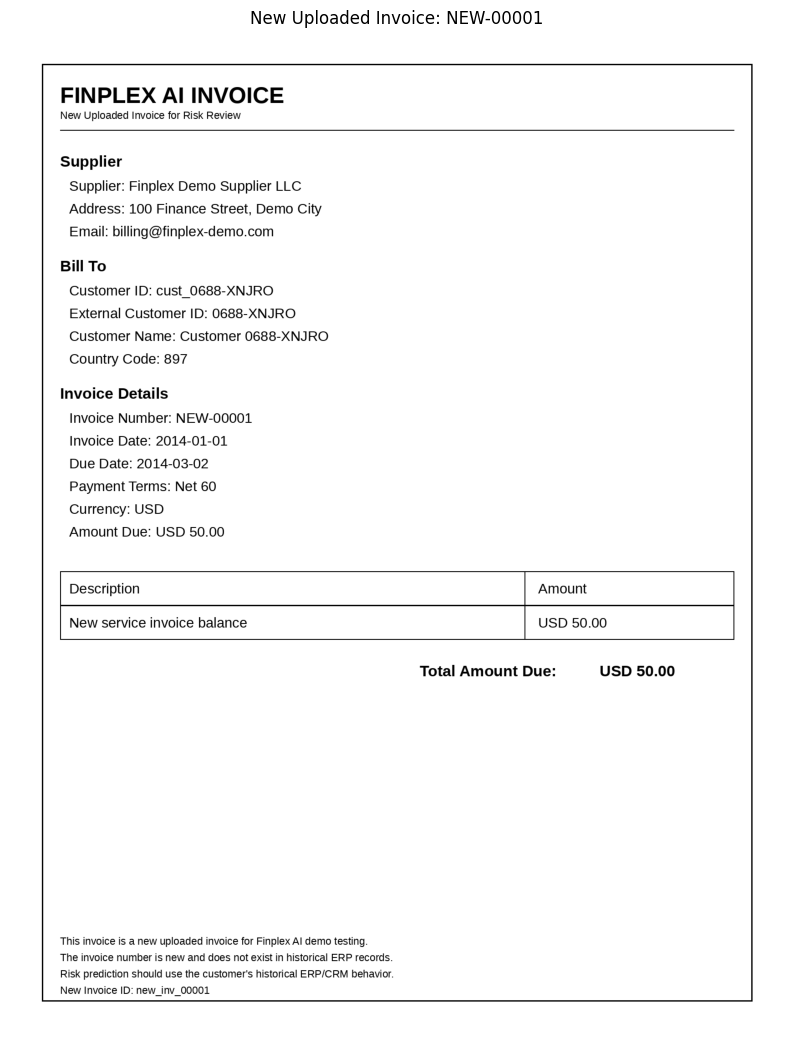

Sample image path: /content/data/demo_invoices/new_uploaded_invoices/NEW-00001.png
{
  "tenant_id": "tenant_demo",
  "new_invoice_id": "new_inv_00001",
  "invoice_number": "NEW-00001",
  "finplex_customer_id": "cust_0688-XNJRO",
  "external_customer_id": "0688-XNJRO",
  "customer_name": "Customer 0688-XNJRO",
  "country_code": "897",
  "invoice_date": "2014-01-01",
  "due_date": "2014-03-02",
  "payment_terms_days": 60,
  "amount_due": 50.0,
  "currency": "USD",
  "image_path": "/content/data/demo_invoices/new_uploaded_invoices/NEW-00001.png"
}


In [10]:
sample_invoice_record = new_uploaded_invoice_truth_df.iloc[0]
sample_image_path = Path(sample_invoice_record["image_path"])

sample_image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(10, 13))
plt.imshow(sample_image)
plt.axis("off")
plt.title(f"New Uploaded Invoice: {sample_invoice_record['invoice_number']}")
plt.show()

print("Sample image path:", sample_image_path)
print(json.dumps(sample_invoice_record.to_dict(), indent=2))

## 11. Run OCR on the New Invoice Image

This section simulates the model-server extraction step.

The input is the invoice image only. The output is structured invoice data that the backend can use for customer matching and risk prediction.

In [11]:
def preprocess_for_ocr(image: Image.Image) -> Image.Image:
    image_array = cv2.cvtColor(
        src=np.array(image),
        code=cv2.COLOR_RGB2GRAY,
    )

    image_array = cv2.threshold(
        image_array,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )[1]

    return Image.fromarray(image_array)


def run_ocr(image_path: Path) -> str:
    image = Image.open(image_path).convert("RGB")
    processed_image = preprocess_for_ocr(image)

    text = pytesseract.image_to_string(
        processed_image,
        config="--psm 6",
    )

    return text


def clean_value(value: str | None) -> str | None:
    if value is None:
        return None

    value = re.sub(r"\s+", " ", str(value)).strip()
    value = value.strip(":-|,. ")

    return value or None


def extract_with_pattern(pattern: str, text: str) -> str | None:
    match = re.search(pattern, text, flags=re.IGNORECASE)

    if not match:
        return None

    return clean_value(match.group(1))


def parse_amount(value: str | None) -> float | None:
    if value is None:
        return None

    cleaned = str(value).replace(",", "")
    cleaned = re.sub(r"[^0-9.]", "", cleaned)

    try:
        return round(float(cleaned), 2)
    except ValueError:
        return None


def extract_invoice_fields_from_text(text: str) -> dict:
    invoice_number = extract_with_pattern(
        r"Invoice\s+Number\s*:\s*([A-Za-z0-9_\-]+)",
        text,
    )

    customer_id = extract_with_pattern(
        r"Customer\s+ID\s*:\s*([A-Za-z0-9_\-]+)",
        text,
    )

    external_customer_id = extract_with_pattern(
        r"External\s+Customer\s+ID\s*:\s*([A-Za-z0-9_\-]+)",
        text,
    )

    customer_name = extract_with_pattern(
        r"Customer\s+Name\s*:\s*(.+)",
        text,
    )

    invoice_date = extract_with_pattern(
        r"Invoice\s+Date\s*:\s*([0-9]{4}-[0-9]{2}-[0-9]{2})",
        text,
    )

    due_date = extract_with_pattern(
        r"Due\s+Date\s*:\s*([0-9]{4}-[0-9]{2}-[0-9]{2})",
        text,
    )

    payment_terms_raw = extract_with_pattern(
        r"Payment\s+Terms\s*:\s*Net\s*([0-9]+)",
        text,
    )

    country_code = extract_with_pattern(
        r"Country\s+Code\s*:\s*([A-Za-z0-9_\-]+)",
        text,
    )

    amount_raw = extract_with_pattern(
        r"Amount\s+Due\s*:\s*USD\s*([0-9,]+\.[0-9]{2})",
        text,
    )

    if amount_raw is None:
        amount_raw = extract_with_pattern(
            r"Total\s+Amount\s+Due\s*:\s*USD\s*([0-9,]+\.[0-9]{2})",
            text,
        )

    return {
        "invoice_number": invoice_number,
        "customer_id": customer_id,
        "external_customer_id": external_customer_id,
        "customer_name": customer_name,
        "invoice_date": invoice_date,
        "due_date": due_date,
        "payment_terms_days": int(payment_terms_raw) if payment_terms_raw else None,
        "amount_due": parse_amount(amount_raw),
        "currency": "USD" if amount_raw else None,
        "country_code": country_code,
        "raw_ocr_text": text,
        "extraction_method": "new_invoice_tesseract_rules",
    }


sample_ocr_text = run_ocr(sample_image_path)
sample_extracted_fields = extract_invoice_fields_from_text(sample_ocr_text)

print("OCR text preview:")
print(sample_ocr_text[:2000])

print("\nExtracted fields:")
print(json.dumps(sample_extracted_fields, indent=2))

OCR text preview:
FINPLEX Al INVOICE
New Uploaded Invoice for Risk Review
Supplier

Supplier: Finplex Demo Supplier LLC

Address: 100 Finance Street, Demo City

Email: billing@finplex-demo.com
Bill To

Customer ID: cust_0688-XNJRO

External Customer ID: 0688-XNJRO

Customer Name: Customer 0688-XNJRO

Country Code: 897
Invoice Details

Invoice Number: NEW-00001

Invoice Date: 2014-01-01

Due Date: 2014-03-02

Payment Terms: Net 60

Currency: USD

Amount Due: USD 50.00

Total Amount Due: USD 50.00

This invoice is a new uploaded invoice for Finplex Al demo testing.
The invoice number is new and does not exist in historical ERP records.
Risk prediction should use the customer's historical ERP/CRM behavior.
New Invoice ID: new_inv_00001


Extracted fields:
{
  "invoice_number": "NEW-00001",
  "customer_id": "cust_0688-XNJRO",
  "external_customer_id": "0688-XNJRO",
  "customer_name": "Customer 0688-XNJRO",
  "invoice_date": "2014-01-01",
  "due_date": "2014-03-02",
  "payment_terms_days":

## 12. Evaluate One Invoice Extraction

This section compares extracted OCR fields against the known ground truth for the generated new invoice.

The ground truth is used only for extraction evaluation. It is not used for risk lookup.

In [13]:
EVALUATED_FIELDS = [
    "invoice_number",
    "customer_id",
    "external_customer_id",
    "customer_name",
    "invoice_date",
    "due_date",
    "payment_terms_days",
    "amount_due",
    "currency",
    "country_code",
]


GROUND_TRUTH_FIELD_MAP = {
    "invoice_number": "invoice_number",
    "customer_id": "finplex_customer_id",
    "external_customer_id": "external_customer_id",
    "customer_name": "customer_name",
    "invoice_date": "invoice_date",
    "due_date": "due_date",
    "payment_terms_days": "payment_terms_days",
    "amount_due": "amount_due",
    "currency": "currency",
    "country_code": "country_code",
}


def normalize_text(value) -> str | None:
    if value is None or pd.isna(value):
        return None

    value = str(value).lower().strip()
    value = re.sub(r"\s+", " ", value)
    value = value.strip(":-|,. ")

    return value or None


def normalize_number(value) -> float | None:
    if value is None or pd.isna(value):
        return None

    try:
        return round(float(value), 2)
    except ValueError:
        return parse_amount(str(value))


def values_match(field_name: str, expected, extracted) -> bool:
    if field_name == "amount_due":
        expected_number = normalize_number(expected)
        extracted_number = normalize_number(extracted)

        if expected_number is None or extracted_number is None:
            return expected_number == extracted_number

        return abs(expected_number - extracted_number) <= 0.01

    if field_name == "payment_terms_days":
        try:
            return int(expected) == int(extracted)
        except Exception:
            return False

    return normalize_text(expected) == normalize_text(extracted)


def build_expected_fields(row: pd.Series) -> dict:
    expected = {}

    for field_name, source_column in GROUND_TRUTH_FIELD_MAP.items():
        expected[field_name] = row[source_column]

    return expected


def evaluate_one_invoice(expected: dict, extracted: dict) -> pd.DataFrame:
    rows = []

    for field_name in EVALUATED_FIELDS:
        expected_value = expected.get(field_name)
        extracted_value = extracted.get(field_name)

        rows.append(
            {
                "field": field_name,
                "expected": expected_value,
                "extracted": extracted_value,
                "match": values_match(
                    field_name,
                    expected_value,
                    extracted_value,
                ),
            }
        )

    return pd.DataFrame(rows)


sample_expected = build_expected_fields(sample_invoice_record)

sample_evaluation_df = evaluate_one_invoice(
    expected=sample_expected,
    extracted=sample_extracted_fields,
)

sample_evaluation_df

,field,expected,extracted,match
0,invoice_number,NEW-00001,NEW-00001,True
1,customer_id,cust_0688-XNJRO,cust_0688-XNJRO,True
2,external_customer_id,0688-XNJRO,0688-XNJRO,True
3,customer_name,Customer 0688-XNJRO,Customer 0688-XNJRO,True
4,invoice_date,2014-01-01,2014-01-01,True
5,due_date,2014-03-02,2014-03-02,True
6,payment_terms_days,60,60,True
7,amount_due,50.0,50.0,True
8,currency,USD,USD,True
9,country_code,897,897,True


## 13. Match Extracted Customer to Historical CRM Data

This step shows the useful part of the application.

The uploaded invoice is new, so the application should not look for the same invoice number in historical ERP. Instead, it should use the extracted customer ID or customer name to find the customer's historical behavior.

In [14]:
def match_customer_to_crm(extracted_fields: dict, crm_df: pd.DataFrame) -> pd.DataFrame:
    extracted_customer_id = extracted_fields.get("customer_id")
    extracted_external_customer_id = extracted_fields.get("external_customer_id")
    extracted_customer_name = extracted_fields.get("customer_name")

    if extracted_customer_id:
        matched = crm_df[
            crm_df["finplex_customer_id"].astype(str).str.lower()
            == str(extracted_customer_id).lower()
        ]

        if len(matched) > 0:
            return matched.copy()

    if extracted_external_customer_id:
        matched = crm_df[
            crm_df["external_customer_id"].astype(str).str.lower()
            == str(extracted_external_customer_id).lower()
        ]

        if len(matched) > 0:
            return matched.copy()

    if extracted_customer_name:
        matched = crm_df[
            crm_df["customer_name"].astype(str).str.lower()
            == str(extracted_customer_name).lower()
        ]

        if len(matched) > 0:
            return matched.copy()

    return pd.DataFrame()


sample_customer_match_df = match_customer_to_crm(
    extracted_fields=sample_extracted_fields,
    crm_df=crm_customers_df,
)

if len(sample_customer_match_df) == 0:
    print("No matching customer found in CRM history.")
else:
    print("Matched customer historical CRM record:")
    display(sample_customer_match_df)

Matched customer historical CRM record:


,tenant_id,finplex_customer_id,external_customer_id,customer_name,country_code,historical_invoice_count,total_historical_amount,average_invoice_amount,previous_late_payments,average_days_late,max_days_late,disputed_invoice_count,paperless_bill_rate,on_time_payment_rate,crm_negative_signal_score,relationship_age_days
4,tenant_demo,cust_0688-XNJRO,0688-XNJRO,Customer 0688-XNJRO,897,34,1231.45,36.219118,32,14.441176,34,5,0.0,0.059,1.0,1385


## 14. Run Extraction and Customer Matching on All Demo Invoices

This cell evaluates the extraction pipeline across all generated new invoices.

It also checks whether each extracted customer can be matched to historical CRM data.

In [15]:
def process_new_invoice(row: pd.Series) -> dict:
    image_path = Path(row["image_path"])

    ocr_text = run_ocr(image_path)
    extracted = extract_invoice_fields_from_text(ocr_text)

    expected = build_expected_fields(row)

    evaluation_df = evaluate_one_invoice(
        expected=expected,
        extracted=extracted,
    )

    matched_customer_df = match_customer_to_crm(
        extracted_fields=extracted,
        crm_df=crm_customers_df,
    )

    result = {
        "new_invoice_id": row["new_invoice_id"],
        "invoice_number": row["invoice_number"],
        "image_path": str(image_path),
        "field_accuracy": float(evaluation_df["match"].mean()),
        "customer_matched": len(matched_customer_df) > 0,
    }

    if len(matched_customer_df) > 0:
        matched_customer = matched_customer_df.iloc[0].to_dict()

        result["matched_finplex_customer_id"] = matched_customer["finplex_customer_id"]
        result["matched_customer_name"] = matched_customer["customer_name"]
        result["matched_previous_late_payments"] = matched_customer[
            "previous_late_payments"
        ]
        result["matched_on_time_payment_rate"] = matched_customer[
            "on_time_payment_rate"
        ]
        result["matched_crm_negative_signal_score"] = matched_customer[
            "crm_negative_signal_score"
        ]

    for field_name in EVALUATED_FIELDS:
        field_row = evaluation_df[evaluation_df["field"] == field_name].iloc[0]

        result[f"expected_{field_name}"] = field_row["expected"]
        result[f"extracted_{field_name}"] = field_row["extracted"]
        result[f"match_{field_name}"] = bool(field_row["match"])

    return result


extraction_results = []

for _, row in tqdm(
    new_uploaded_invoice_truth_df.iterrows(),
    total=len(new_uploaded_invoice_truth_df),
    desc="Extracting new invoices",
):
    try:
        extraction_results.append(process_new_invoice(row))
    except Exception as exc:
        extraction_results.append(
            {
                "new_invoice_id": row["new_invoice_id"],
                "invoice_number": row["invoice_number"],
                "image_path": row["image_path"],
                "error": str(exc),
            }
        )

extraction_results_df = pd.DataFrame(extraction_results)

display(extraction_results_df.head())

print("Processed new invoices:", len(extraction_results_df))

Extracting new invoices:   0%|          | 0/40 [00:00<?, ?it/s]

,new_invoice_id,invoice_number,image_path,field_accuracy,customer_matched,matched_finplex_customer_id,matched_customer_name,matched_previous_late_payments,matched_on_time_payment_rate,matched_crm_negative_signal_score,...,match_payment_terms_days,expected_amount_due,extracted_amount_due,match_amount_due,expected_currency,extracted_currency,match_currency,expected_country_code,extracted_country_code,match_country_code
0,new_inv_00001,NEW-00001,/content/data/demo_invoices/new_uploaded_invoi...,1.0,True,cust_0688-XNJRO,Customer 0688-XNJRO,32,0.059,1.000,...,True,50.00,50.00,True,USD,USD,True,897,897,True
1,new_inv_00002,NEW-00002,/content/data/demo_invoices/new_uploaded_invoi...,1.0,True,cust_8690-EEBEO,Customer 8690-EEBEO,26,0.161,0.871,...,True,72.74,72.74,True,USD,USD,True,897,897,True
2,new_inv_00003,NEW-00003,/content/data/demo_invoices/new_uploaded_invoi...,1.0,True,cust_8102-ABPKQ,Customer 8102-ABPKQ,26,0.037,1.000,...,True,55.65,55.65,True,USD,USD,True,818,818,True
3,new_inv_00004,NEW-00004,/content/data/demo_invoices/new_uploaded_invoi...,1.0,True,cust_6708-DPYTF,Customer 6708-DPYTF,25,0.167,0.833,...,True,62.90,62.90,True,USD,USD,True,391,391,True
4,new_inv_00005,NEW-00005,/content/data/demo_invoices/new_uploaded_invoi...,1.0,True,cust_4460-ZXNDN,Customer 4460-ZXNDN,25,0.107,1.000,...,True,77.88,77.88,True,USD,USD,True,770,770,True


Processed new invoices: 40


## 15. Calculate Extraction and Matching Metrics

This section calculates field-level extraction accuracy and customer matching success.

The most important production signal is not only whether OCR reads the invoice number. It is whether the system can extract enough customer information to match the new invoice to historical ERP/CRM data.

In [16]:
if "error" in extraction_results_df.columns:
    successful_results_df = extraction_results_df[
        extraction_results_df["error"].isna()
    ].copy()

    failed_results_df = extraction_results_df[
        extraction_results_df["error"].notna()
    ].copy()
else:
    successful_results_df = extraction_results_df.copy()
    failed_results_df = pd.DataFrame()

field_metric_rows = []

for field_name in EVALUATED_FIELDS:
    match_column = f"match_{field_name}"

    field_metric_rows.append(
        {
            "field": field_name,
            "accuracy": float(successful_results_df[match_column].mean()),
            "matched": int(successful_results_df[match_column].sum()),
            "total": int(successful_results_df[match_column].notna().sum()),
        }
    )

field_metrics_df = pd.DataFrame(field_metric_rows)

overall_metrics = {
    "notebook": "01_invoice_document_extraction",
    "dataset_source": DATASET_SLUG,
    "created_at": datetime.now(UTC).isoformat(),
    "historical_erp_rows": int(len(historical_erp_invoices_df)),
    "crm_customer_rows": int(len(crm_customers_df)),
    "new_uploaded_invoice_count": int(len(new_uploaded_invoice_truth_df)),
    "successful_invoice_count": int(len(successful_results_df)),
    "failed_invoice_count": int(len(failed_results_df)),
    "mean_field_accuracy": float(successful_results_df["field_accuracy"].mean()),
    "customer_match_rate": float(successful_results_df["customer_matched"].mean()),
}

display(field_metrics_df)
print(json.dumps(overall_metrics, indent=2))

,field,accuracy,matched,total
0,invoice_number,1.000,40,40
1,customer_id,0.975,39,40
2,external_customer_id,0.975,39,40
3,customer_name,0.975,39,40
4,invoice_date,1.000,40,40
5,due_date,1.000,40,40
6,payment_terms_days,1.000,40,40
7,amount_due,1.000,40,40
8,currency,1.000,40,40
9,country_code,1.000,40,40


{
  "notebook": "01_invoice_document_extraction",
  "dataset_source": "hhenry/finance-factoring-ibm-late-payment-histories",
  "created_at": "2026-06-18T14:20:25.975188+00:00",
  "historical_erp_rows": 2466,
  "crm_customer_rows": 100,
  "new_uploaded_invoice_count": 40,
  "successful_invoice_count": 40,
  "failed_invoice_count": 0,
  "mean_field_accuracy": 0.9925,
  "customer_match_rate": 1.0
}


## 16. Save Extraction Artifacts

This cell saves OCR results, field metrics, customer matching metrics, and the seed data needed by the application.

In [17]:
extraction_results_path = ARTIFACTS_DIR / "new_invoice_extraction_results.csv"
field_metrics_path = ARTIFACTS_DIR / "new_invoice_field_metrics.csv"
overall_metrics_path = ARTIFACTS_DIR / "new_invoice_extraction_metrics.json"

extraction_results_df.to_csv(extraction_results_path, index=False)
field_metrics_df.to_csv(field_metrics_path, index=False)

overall_metrics_path.write_text(
    json.dumps(overall_metrics, indent=2),
    encoding="utf-8",
)

print("Saved extraction results:", extraction_results_path)
print("Saved field metrics:", field_metrics_path)
print("Saved overall metrics:", overall_metrics_path)

Saved extraction results: /content/artifacts/invoice_extraction/new_invoice_extraction_results.csv
Saved field metrics: /content/artifacts/invoice_extraction/new_invoice_field_metrics.csv
Saved overall metrics: /content/artifacts/invoice_extraction/new_invoice_extraction_metrics.json


## 17. Create Downloadable Demo Artifact Package

This ZIP contains:

- historical ERP invoice seed data;
- historical ERP payment seed data;
- CRM customer seed data;
- new uploaded invoice images for the demo;
- ground truth for OCR evaluation;
- extraction and matching metrics.

The React demo can later use the images inside `data/demo_invoices/new_uploaded_invoices/`.

In [18]:
artifact_package_dir = PROJECT_ROOT / "invoice_extraction_artifact_package"

if artifact_package_dir.exists():
    shutil.rmtree(artifact_package_dir)

package_seed_dir = artifact_package_dir / "data" / "seed"
package_demo_invoice_dir = (
    artifact_package_dir / "data" / "demo_invoices" / "new_uploaded_invoices"
)
package_artifact_dir = artifact_package_dir / "artifacts" / "invoice_extraction"

package_seed_dir.mkdir(parents=True, exist_ok=True)
package_demo_invoice_dir.mkdir(parents=True, exist_ok=True)
package_artifact_dir.mkdir(parents=True, exist_ok=True)

for seed_file in [
    historical_erp_invoices_path,
    historical_erp_payments_path,
    crm_customers_path,
    new_uploaded_invoice_truth_path,
]:
    shutil.copy2(seed_file, package_seed_dir / seed_file.name)

for image_file in sorted(DEMO_INVOICE_DIR.glob("*.png")):
    shutil.copy2(image_file, package_demo_invoice_dir / image_file.name)

for artifact_file in [
    extraction_results_path,
    field_metrics_path,
    overall_metrics_path,
]:
    shutil.copy2(artifact_file, package_artifact_dir / artifact_file.name)

artifact_zip_path = PROJECT_ROOT / "invoice_extraction_artifacts.zip"

if artifact_zip_path.exists():
    artifact_zip_path.unlink()

shutil.make_archive(
    base_name=str(artifact_zip_path.with_suffix("")),
    format="zip",
    root_dir=artifact_package_dir,
)

print("Created artifact ZIP:", artifact_zip_path)

try:
    from google.colab import files

    files.download(str(artifact_zip_path))
except Exception:
    print("Download helper is only available in Google Colab.")

Created artifact ZIP: /content/invoice_extraction_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Final Notes

This notebook creates the corrected invoice extraction flow for Finplex AI.

The uploaded invoices are new invoices for existing customers. The system extracts customer and invoice details from the image, then matches the customer to historical ERP/CRM records.

This avoids the wrong workflow of uploading an invoice that already exists in ERP and matching by invoice number.

The correct application flow is:

new invoice image
→ OCR extraction
→ customer matching
→ historical ERP/CRM lookup
→ late-payment risk prediction
→ compliant follow-up draft
→ human approval

Notebook 2 will use the historical ERP/CRM seed data created here to train the late-payment risk model.